In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ml_final_project

Mounted at /content/drive
/content/drive/MyDrive/ml_final_project


In [ ]:
from colab_setup import setup_project

drive_repo = setup_project(repo_url="https://github.com/ochiga07/ml_final_project.git")

import feature_pipeline
import importlib
importlib.reload(feature_pipeline)
from feature_pipeline import load_raw_data, run_feature_pipeline, split_and_save

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0

In [ ]:
import mlflow
import dagshub

dagshub.init(repo_owner='aochi23', repo_name='ml_final_project', mlflow=True)
#mlflow.set_experiment("SARIMA_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=159fa0b4-8092-4b34-a88d-8596c2d24a15&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=8455f295561ce6ba235215fbc10751f473748b5997d585f7cada012c6b7f1fe9




Accessing as aochi23

Initialized MLflow to track repo "aochi23/ml_final_project"

Repository aochi23/ml_final_project initialized!

In [ ]:
train, test, features, stores = load_raw_data(path=f'{drive_repo}/data/')
full_df = run_feature_pipeline(train, test, features, stores)
processed_train, processed_test = split_and_save(full_df)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
with mlflow.start_run(run_name="SARIMA_Preprocessing"):
    non_sparse = processed_train[processed_train['is_sparse'] == False]
    volume_by_pair = non_sparse.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False)
    n_total = len(volume_by_pair)

    np.random.seed(42)
    high_vol = volume_by_pair.iloc[:n_total // 3]
    mid_vol = volume_by_pair.iloc[n_total // 3: 2 * n_total // 3]
    low_vol = volume_by_pair.iloc[2 * n_total // 3:]

    sample_pairs = (list(high_vol.sample(5).index) +
        list(mid_vol.sample(5).index) + list(low_vol.sample(5).index))

    stationarity_results = []

    for store, dept in sample_pairs:
        subset = processed_train[
            (processed_train['Store'] == store) &
            (processed_train['Dept'] == dept)
        ].sort_values('Date')

        series = subset.set_index('Date')['Weekly_Sales']
        train_series = series[:-12]
        adf_pvalue = adfuller(train_series)[1]
        stationarity_results.append({
            'Store': store, 'Dept': dept,
            'n_weeks': len(series),
            'adf_pvalue': adf_pvalue,
            'stationary': adf_pvalue < 0.05
        })

    stationarity_df = pd.DataFrame(stationarity_results)
    n_stationary = stationarity_df['stationary'].sum()

    mlflow.log_param("min_weeks_threshold", 52)
    mlflow.log_param("n_series_sampled", len(sample_pairs))
    mlflow.log_param("sampling_strategy", "stratified_by_volume_5_5_5")
    mlflow.log_param("validation_weeks", 12)
    mlflow.log_metric("n_stationary_series", n_stationary)
    mlflow.log_metric("n_nonstationary_series", len(sample_pairs) - n_stationary)
    mlflow.log_metric("pct_stationary", n_stationary / len(sample_pairs))

    stationarity_path = f"{drive_repo}/sarima_stationarity.csv"
    stationarity_df.to_csv(stationarity_path, index=False)
    mlflow.log_artifact(stationarity_path)

    print(stationarity_df)
    print(f"\n{n_stationary}/{len(sample_pairs)} series are stationary (ADF with p < 0.05)")

    Store  Dept  n_weeks    adf_pvalue  stationary
0      11    79      143  1.934941e-01       False
1      40     9      143  5.822119e-02       False
2      37    95      143  1.684752e-03        True
3       6    87      143  7.791159e-01       False
4       8    87      143  8.701641e-01       False
5      24    25      143  1.498365e-07        True
6      32    16      143  1.842348e-03        True
7       6    25      143  8.387345e-04        True
8       8    22      143  2.004005e-03        True
9       9     3      143  6.580216e-05        True
10      1    27      143  1.078307e-03        True
11      5    55      143  4.146046e-03        True
12     13    27      143  2.386389e-06        True
13     10    36      143  1.272071e-03        True
14     10    45       79  1.566152e-03        True

11/15 series are stationary (ADF with p < 0.05)
🏃 View run SARIMA_Preprocessing at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/e63a5e6eefa94d73b8efa4a27e

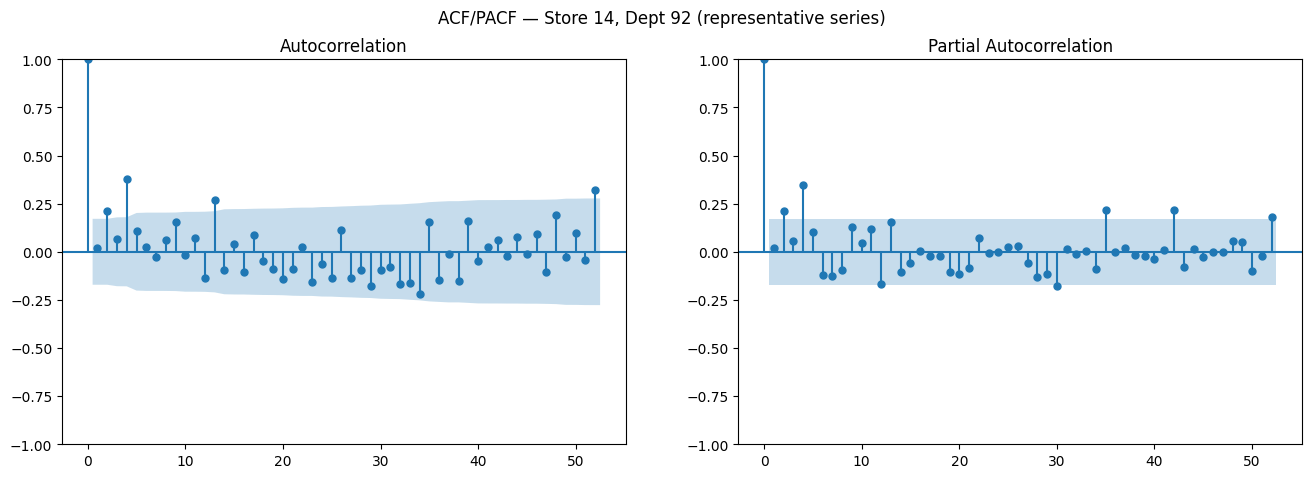

Representative series: Store 14, Dept 92
Order selected: SARIMA(1,1,1)(1,1,1,52)
🏃 View run SARIMA_Order_Selection at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/70f18dd2dafd49d1815596031db54068
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0


In [ ]:
with mlflow.start_run(run_name="SARIMA_Order_Selection"):
    rep_store, rep_dept = volume_by_pair.index[0]
    subset = processed_train[
        (processed_train['Store'] == rep_store) &
        (processed_train['Dept'] == rep_dept)
    ].sort_values('Date')
    rep_series = subset.set_index('Date')['Weekly_Sales'][:-12]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(rep_series, lags=52, ax=axes[0])
    plot_pacf(rep_series, lags=52, ax=axes[1])
    plt.suptitle(f'ACF/PACF — Store {rep_store}, Dept {rep_dept} (representative series)')
    acf_path = f"{drive_repo}/sarima_acf_pacf.png"
    plt.savefig(acf_path)
    plt.show()

    mlflow.log_param("p", 1)
    mlflow.log_param("d", 1)
    mlflow.log_param("q", 1)
    mlflow.log_param("P", 1)
    mlflow.log_param("D", 1)
    mlflow.log_param("Q", 1)
    mlflow.log_param("s", 52)
    mlflow.log_param("order_selection_method", "ACF_PACF_analysis")
    mlflow.log_param("representative_series", f"Store_{rep_store}_Dept_{rep_dept}")
    mlflow.log_param(
        "order_reasoning",
        "d=1: most individual series non-stationary unlike aggregate. "
        "p=1,q=1: single significant spike in PACF/ACF at lag 1. "
        "D=1,s=52: strong lag-52 spike in ACF confirms yearly seasonality. "
        "P=1,Q=1: standard starting point for seasonal component."
    )
    mlflow.log_artifact(acf_path)

    print(f"Representative series: Store {rep_store}, Dept {rep_dept}")
    print("Order selected: SARIMA(1,1,1)(1,1,1,52)")

In [ ]:
def fit_and_evaluate_sarima(series_df, store, dept, n_test=12, order=(1,1,1), seasonal_order=(1,1,1,52)):
    subset = series_df[
        (series_df['Store'] == store) &
        (series_df['Dept'] == dept)
    ].sort_values('Date')
    series = subset.set_index('Date')['Weekly_Sales']

    if len(series) < n_test + seasonal_order[3] + 10:
        return None

    train_series = series[:-n_test]
    val_series = series[-n_test:]

    try:
        model = SARIMAX(
            train_series,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        forecast = results.get_forecast(steps=n_test)
        pred_mean = forecast.predicted_mean

        mae  = mean_absolute_error(val_series, pred_mean)
        rmse = np.sqrt(np.mean((val_series.values - pred_mean.values) ** 2))

        return {
            'Store': store, 'Dept': dept,
            'n_weeks': len(series),
            'adf_pvalue': adfuller(train_series)[1],
            'mae': mae, 'rmse': rmse, 'aic': results.aic,
            'series': series,
            'train_series': train_series,
            'val_series': val_series,
            'pred_mean': pred_mean,
            'results': results
        }
    except Exception as e:
        print(f"Failed — Store {store}, Dept {dept}: {e}")
        return None

results_list = []
for store, dept in sample_pairs:
    print(f"Fitting Store {store}, Dept {dept}")
    result = fit_and_evaluate_sarima(processed_train, store, dept)
    if result is not None:
        results_list.append(result)

print(f"\nFit {len(results_list)}/{len(sample_pairs)} series")

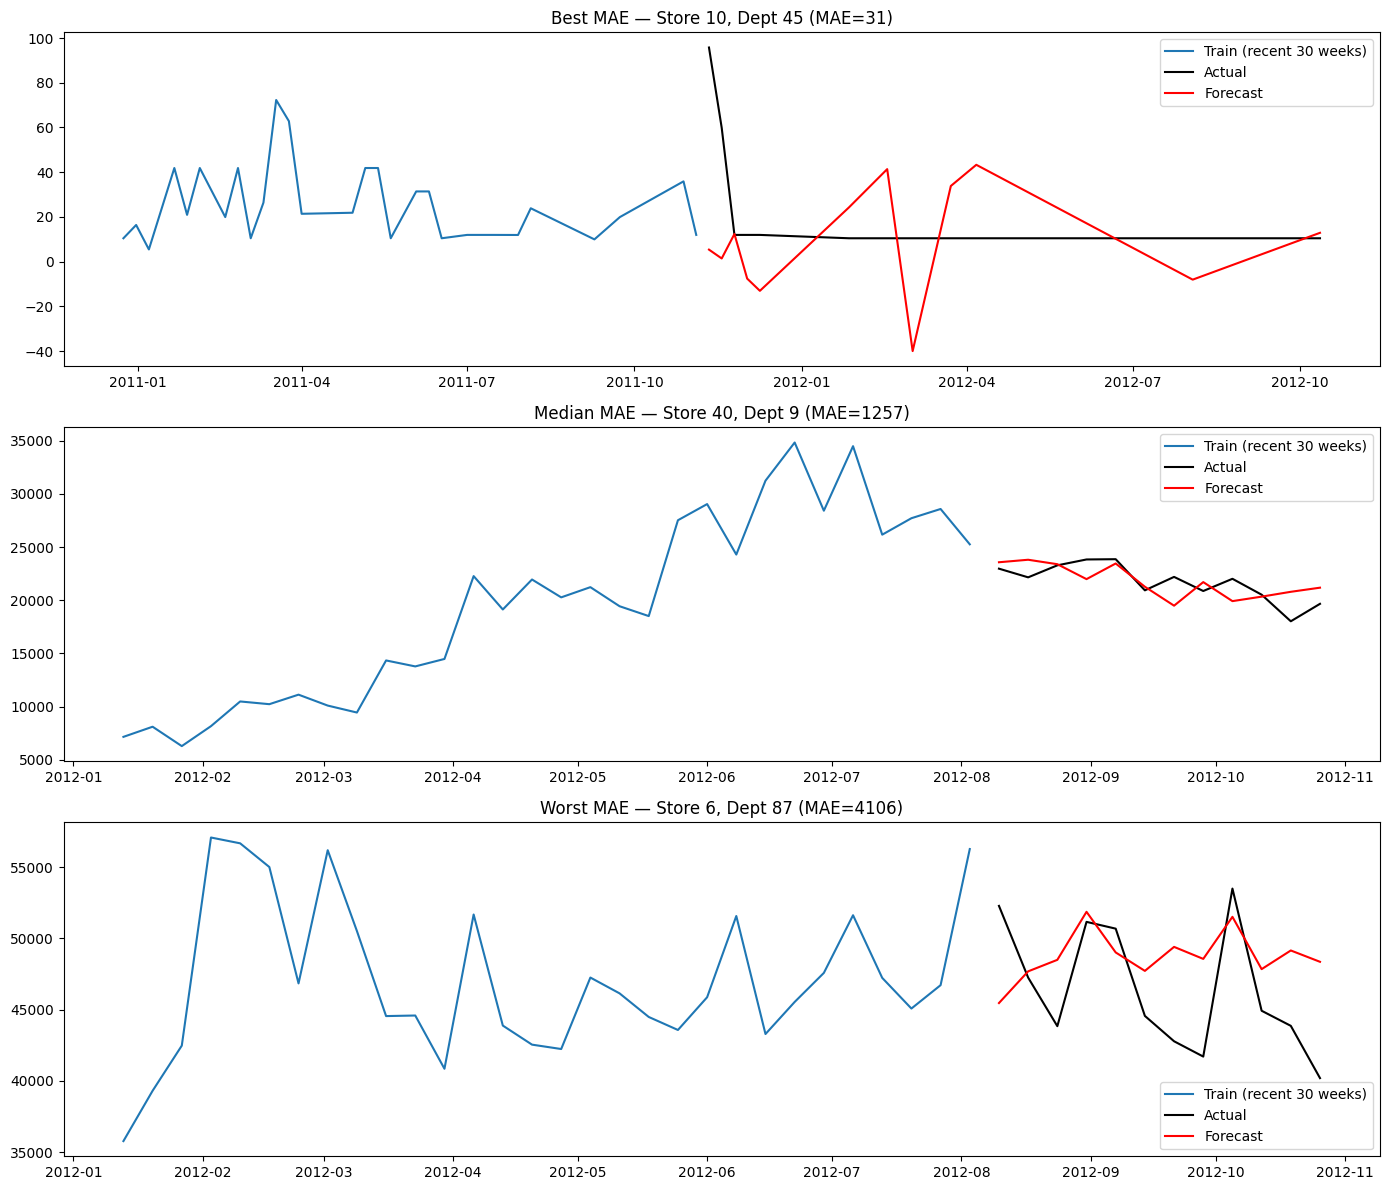

Mean MAE: 1581.47
Median MAE: 1256.81
    Store  Dept  n_weeks    adf_pvalue          mae         rmse         aic
14     10    45       79  1.566152e-03    30.505541    38.998460   10.000000
10      1    27      143  1.078307e-03   175.697875   227.721608  316.661265
11      5    55      143  4.146046e-03   491.262257   564.254896  379.415684
12     13    27      143  2.386389e-06   777.122469   977.113223  343.314887
13     10    36      143  1.272071e-03   974.209693  1067.173199  411.739437
8       8    22      143  2.004005e-03   998.510593  1315.616352  416.822626
5      24    25      143  1.498365e-07  1111.613075  1366.588577  429.649006
1      40     9      143  5.822119e-02  1256.808822  1562.651357  452.137462
7       6    25      143  8.387345e-04  1412.112008  1710.904807  425.755274
2      37    95      143  1.684752e-03  1494.852355  1703.160481  438.127852
6      32    16      143  1.842348e-03  1512.909984  1772.845722  485.702776
0      11    79      143  1.934941e-01

In [ ]:
with mlflow.start_run(run_name="SARIMA_Evaluation"):
    summary_df = pd.DataFrame([{
        'Store': r['Store'], 'Dept': r['Dept'],
        'n_weeks': r['n_weeks'], 'adf_pvalue': r['adf_pvalue'],
        'mae': r['mae'], 'rmse': r['rmse'], 'aic': r['aic']
    } for r in results_list])

    summary_df = summary_df.sort_values('mae')

    mean_mae = summary_df['mae'].mean()
    median_mae = summary_df['mae'].median()
    mean_rmse = summary_df['rmse'].mean()
    median_rmse = summary_df['rmse'].median()

    mlflow.log_metric("mean_mae", mean_mae)
    mlflow.log_metric("median_mae", median_mae)
    mlflow.log_metric("mean_rmse", mean_rmse)
    mlflow.log_metric("median_rmse", median_rmse)
    mlflow.log_metric("n_series_evaluated", len(results_list))
    mlflow.log_param("order", "(1,1,1)")
    mlflow.log_param("seasonal_order", "(1,1,1,52)")

    summary_path = f"{drive_repo}/sarima_results_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    mlflow.log_artifact(summary_path)

    sorted_results = sorted(results_list, key=lambda r: r['mae'])
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    for ax, idx, label in zip(axes, [0, len(sorted_results)//2, -1],
                               ['Best MAE', 'Median MAE', 'Worst MAE']):
        r = sorted_results[idx]
        ax.plot(r['train_series'].index[-30:], r['train_series'].values[-30:], label='Train (recent 30 weeks)')
        ax.plot(r['val_series'].index,  r['val_series'].values, label='Actual', color='black')
        ax.plot(r['val_series'].index,  r['pred_mean'].values, label='Forecast', color='red')
        ax.set_title(f"{label} — Store {r['Store']}, Dept {r['Dept']} (MAE={r['mae']:.0f})")
        ax.legend()

    plt.tight_layout()
    plots_path = f"{drive_repo}/sarima_forecast_plots.png"
    plt.savefig(plots_path)
    plt.show()
    mlflow.log_artifact(plots_path)

    print(f"Mean MAE: {mean_mae:.2f}")
    print(f"Median MAE: {median_mae:.2f}")
    print(summary_df)

In [ ]:
subset = processed_train[
    (processed_train['Store'] == 10) &
    (processed_train['Dept'] == 45)
].sort_values('Date')

print(subset['Weekly_Sales'].describe())
print(f"\nSeries std: {subset['Weekly_Sales'].std():.2f}")

count     79.000000
mean      33.193038
std       29.208583
min      -21.480000
25%       11.440000
50%       23.880000
75%       46.525000
max      155.960000
Name: Weekly_Sales, dtype: float64

Series std: 29.21


In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
class SARIMAWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, order=(1,1,1), seasonal_order=(1,1,1,52)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.fitted_results = None

    def fit(self, series, y=None):
        model = SARIMAX(
            series,
            order=self.order,
            seasonal_order=self.seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        self.fitted_results = model.fit(disp=False)
        return self

    def predict(self, n_steps):
        forecast = self.fitted_results.get_forecast(steps=n_steps)
        return forecast.predicted_mean.values


best_result = sorted_results[0]
best_series = best_result['train_series']

sarima_model = SARIMAWrapper(order=(1,1,1), seasonal_order=(1,1,1,52))
sarima_pipeline = Pipeline(steps=[('sarima', sarima_model)])
sarima_pipeline.fit(best_series)

with mlflow.start_run(run_name="SARIMA_Best_Model"):
    mlflow.log_param("best_store", best_result['Store'])
    mlflow.log_param("best_dept", best_result['Dept'])
    mlflow.log_param("best_mae", best_result['mae'])
    mlflow.log_param("order", str((1,1,1)))
    mlflow.log_param("seasonal_order",str((1,1,1,52)))

    mlflow.sklearn.log_model(
        sk_model=sarima_pipeline,
        artifact_path="sarima_pipeline",
        registered_model_name="SARIMA_Pipeline"
    )
    print(f"Saved SARIMA pipeline - Store {best_result['Store']}, "
          f"Dept {best_result['Dept']}, MAE={best_result['mae']:.2f}")